**Problem Statement:** Household energy usage fluctuates over time due to varying human activities, weather conditions, and seasonal changes. These fluctuations make it difficult to estimate future electricity demand without a systematic approach. The problem is to analyze historical energy consumption data and build a time series forecasting model that can predict short-term future energy usage. Accurate predictions are essential for improving energy efficiency, preventing overloads, and assisting utility providers in demand planning and load balancing.

**Objective:** The objective of this task is to develop a short-term forecasting model that predicts household energy consumption based on historical time-series data. By analyzing past usage patterns such as daily, weekly, and seasonal trends, the model aims to estimate future energy demand accurately. This helps in understanding consumption behavior and supports efficient energy management, cost reduction, and better resource planning.

**Data Loading:** It is the process of importing the dataset into the working environment for analysis. The dataset usually in CSV format is loaded into a pandas DataFrame to make it easy to work with. This step also includes an initial check of the dataset structure, such as columns, data types, and missing values. Proper data loading ensures the dataset is correctly prepared for further steps like cleaning, preprocessing, and model building.

In [2]:
#Import required libraries
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

#Load the dataset
df = pd.read_csv("household power consumption.csv")

#Display the dataset
print(df.head())

Saving household power consumption.csv to household power consumption (1).csv
         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


**Dataset Description:** The dataset used in this project contains household electric power consumption data recorded over a specific **date and time period.** It is a time series dataset where each observation is linked with a timestamp (date and time), allowing detailed analysis of electricity usage patterns over time.

The dataset includes several important variables such as **Global Active Power**, which represents the actual electricity consumed by household appliances, and **Global Reactive Power**, which indicates the non-working power in the system. It also contains **Voltage**, which measures the electrical potential supplied to the household at each time interval.

In addition, **Global Intensity** is included, which represents the total current drawn and reflects the overall electrical load, similar in importance to sub-metering variables. The dataset further contains **Sub Metering values (1, 2, and 3)**, which show energy consumption in different areas or appliance groups within the household. Together, these variables combined with timestamp information provide a complete view of household energy usage and are essential for identifying patterns and building accurate forecasting models.



In [3]:
#Display shape of dataset
print("Dataset Shape:", df.shape)

#Display column names
print("\nColumns:")
print(df.columns)

#Display information about dataset
print("\nDataset Info:")
print(df.info())

#Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1500000, 9)

Columns:
Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1500000 non-null  object 
 1   Time                   1500000 non-null  object 
 2   Global_active_power    1500000 non-null  object 
 3   Global_reactive_power  1500000 non-null  object 
 4   Voltage                1500000 non-null  object 
 5   Global_intensity       1500000 non-null  object 
 6   Sub_metering_1         1500000 non-null  object 
 7   Sub_metering_2         1500000 non-null  object 
 8   Sub_metering_3         1491653 non-null  float64
dtypes: float64(1), object(8)
memory usage: 103.

**Data Cleaning** involves identifying and correcting errors, missing values, duplicates, and inconsistencies in the dataset to ensure high data quality. In household energy consumption data, missing values are often handled using techniques such as forward fill or backward fill, while duplicate records are removed to avoid bias in analysis. Outliers, such as unusually high or low energy usage values, are also detected and treated because they can distort model performance. Additionally, ensuring that all variables have the correct data types, especially converting numerical and datetime columns properly, is an essential part of cleaning.

**Preprocessing** transforms the data into a suitable format for machine learning. This includes structuring the dataset as a time-indexed series, sorting it in chronological order, and extracting meaningful time-based features such as hour, day, month, and weekday. These steps help the model better understand patterns and seasonality in energy consumption data, ultimately improving forecasting accuracy.

In [4]:
#Replace '?' with NaN values
df.replace('?', np.nan, inplace=True)

#Convert important columns to numeric datatype
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col])

#Check missing values after conversion
print(df.isnull().sum())

#Fill missing values using forward fill method
df.ffill(inplace=True)

#Verify missing values are handled
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

#Display cleaned dataset
print(df.head())

Date                        0
Time                        0
Global_active_power      8347
Global_reactive_power    8347
Voltage                  8347
Global_intensity         8347
Sub_metering_1           8347
Sub_metering_2           8347
Sub_metering_3           8347
dtype: int64

Missing Values After Cleaning:
Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00      

**Parsing** refers to the process of converting raw date and time information, which is usually stored as text, into a proper datetime format that can be understood and processed by Python. This allows the dataset to be indexed by time, sorted chronologically, and used for extracting temporal features.

**Resampling** refers to changing the frequency of the time series data to a different time interval, such as converting hourly data into daily, weekly, or monthly data. This process helps in reducing noise, identifying long-term trends, and making the dataset more suitable for forecasting models. For example, hourly energy consumption data can be resampled into daily total usage or monthly averages to better understand consumption patterns over time. Common resampling frequencies include hourly (H), daily (D), weekly (W), and monthly (M). Together, parsing and resampling ensure that time series data is properly structured and meaningful for accurate prediction and analysis.

In [5]:
#Replace missing symbols
df.replace('?', pd.NA, inplace=True)

#Combine Date and Time columns into a single datetime column
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

#Set Datetime as index
df.set_index('Datetime', inplace=True)

#Convert Global Active Power to numeric
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

#Fill missing values
df['Global_active_power'] = df['Global_active_power'].ffill()

#Resample data hourly using mean
hourly_data = df['Global_active_power'].resample('h').mean()

#Resample data daily using mean
daily_data = df['Global_active_power'].resample('D').mean()

#Display results
print("Hourly Resampled Data:")
print(hourly_data.head())

print("\nDaily Resampled Data:")
print(daily_data.head())

Hourly Resampled Data:
Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

Daily Resampled Data:
Datetime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-18    1.530435
2006-12-19    1.157079
2006-12-20    1.545658
Freq: D, Name: Global_active_power, dtype: float64


**Time-based Feature Engineering** is an important step in energy consumption time series forecasting because electricity usage patterns often depend on specific times and days.

After converting the dataset into a proper datetime format and setting it as the index, several useful features can be extracted from the timestamp information.

The **Hour feature** represents the hour of the day (0–23) and helps the model identify daily consumption patterns, such as higher electricity usage during mornings or evenings.

The **Day Name** and **Weekday features** capture the day of the week, allowing the model to distinguish between weekdays and weekends, since energy consumption behavior may vary depending on work schedules and household activities.

Additionally, a Weekend feature is created as a binary indicator where 1 represents weekends (Saturday and Sunday) and 0 represents weekdays. These engineered features provide meaningful temporal information to machine learning or forecasting models, improving their ability to recognize trends, seasonality, and recurring consumption behaviors over time.

In [ ]:
#Replace missing symbols
df.replace('?', pd.NA, inplace=True)

#Create datetime column
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

#Set datetime as index
df.set_index('Datetime', inplace=True)

#Create Hour feature
df['Hour'] = df.index.hour

#Create Day Name feature
df['Day_Name'] = df.index.day_name()

#Create Weekday Number feature
#Monday = 0, Sunday = 6
df['Weekday'] = df.index.weekday

#Create Weekend feature
#1 = Weekend, 0 = Weekday
df['Weekend'] = df['Weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)

#Display engineered features
print(df[['Hour', 'Day_Name', 'Weekday', 'Weekend']].head())

                     Hour  Day_Name  Weekday  Weekend
Datetime                                             
2006-12-16 17:24:00    17  Saturday        5        1
2006-12-16 17:25:00    17  Saturday        5        1
2006-12-16 17:26:00    17  Saturday        5        1
2006-12-16 17:27:00    17  Saturday        5        1
2006-12-16 17:28:00    17  Saturday        5        1


**Exploratory Data Analysis (EDA)** is the process of analyzing and visualizing the dataset to better understand its structure, patterns, trends, and relationships before building a forecasting model.

In energy consumption time series forecasting, EDA helps identify important characteristics such as missing values, unusual spikes, seasonal trends, daily or hourly usage patterns, and data distribution.

Through summary statistics and visualizations, we can observe how energy consumption changes over time and detect anomalies or inconsistencies that may affect model performance.

EDA also helps in understanding correlations between variables and provides insights for feature engineering and data preprocessing. Performing EDA ensures that the dataset is clean, meaningful, and suitable for accurate forecasting analysis.

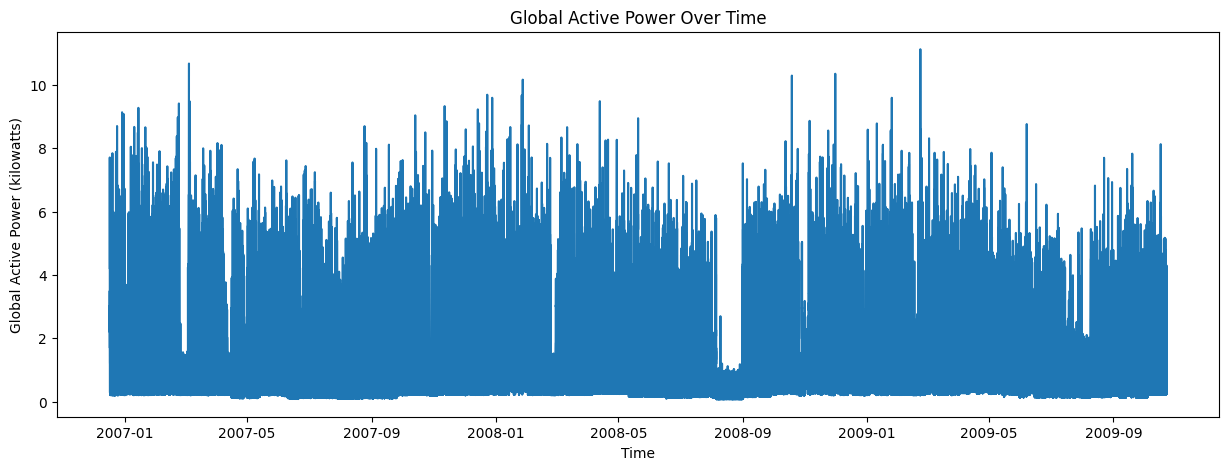

In [ ]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Visualize Energy Consumption Overtime

#Create figure size
plt.figure(figsize=(15,5))

#Plot Global Active Power
plt.plot(df['Global_active_power'])

#Add title and labels
plt.title("Global Active Power Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kilowatts)")

#Display plot
plt.show()

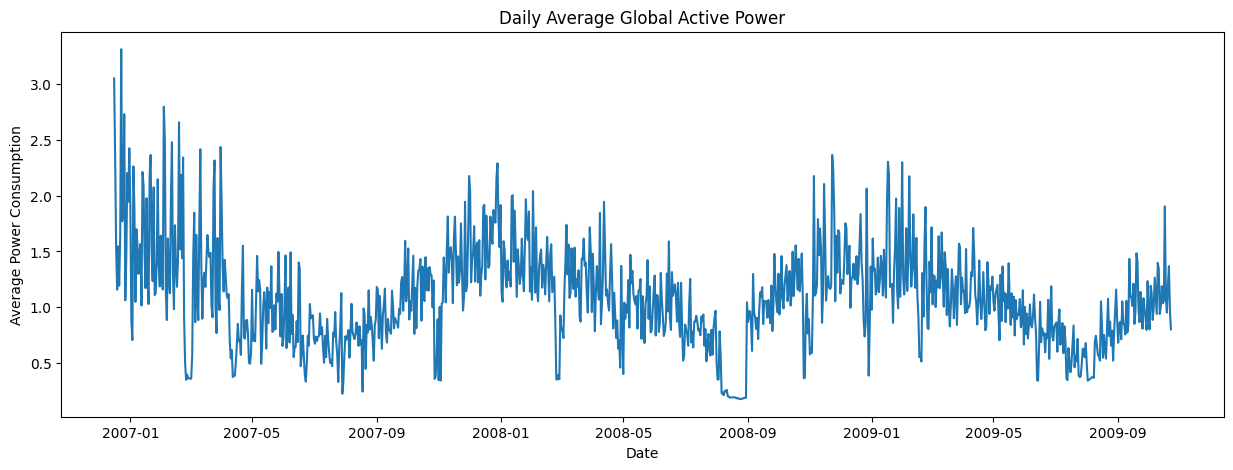

In [ ]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Daily Average Energy Consumption

#Resample data by day and calculate mean
daily_power = df['Global_active_power'].resample('D').mean()

#Plot daily average power consumption
plt.figure(figsize=(15,5))
plt.plot(daily_power)

#Add title and labels
plt.title("Daily Average Global Active Power")
plt.xlabel("Date")
plt.ylabel("Average Power Consumption")

#Display plot
plt.show()

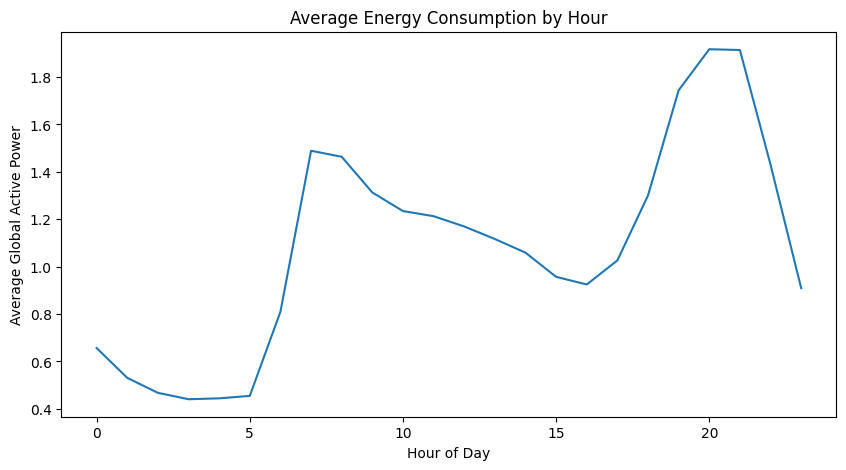

In [ ]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Hourly Energy Consumption Pattern

#Create Hour feature
df['Hour'] = df.index.hour

#Calculate average consumption by hour
hourly_avg = df.groupby('Hour')['Global_active_power'].mean()

#Plot hourly average consumption
plt.figure(figsize=(10,5))
plt.plot(hourly_avg)

#Add chart labels
plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power")

#Display plot
plt.show()

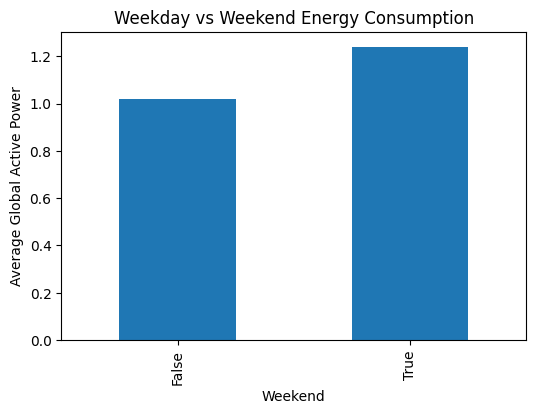

In [ ]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Weekday vs Weekend Analysis

#Create Weekend feature
df['Weekend'] = df.index.weekday >= 5

#Calculate average power usage
weekend_avg = df.groupby('Weekend')['Global_active_power'].mean()

#Create bar chart
plt.figure(figsize=(6,4))
weekend_avg.plot(kind='bar')

#Add labels and title
plt.title("Weekday vs Weekend Energy Consumption")
plt.xlabel("Weekend")
plt.ylabel("Average Global Active Power")

#Display plot
plt.show()


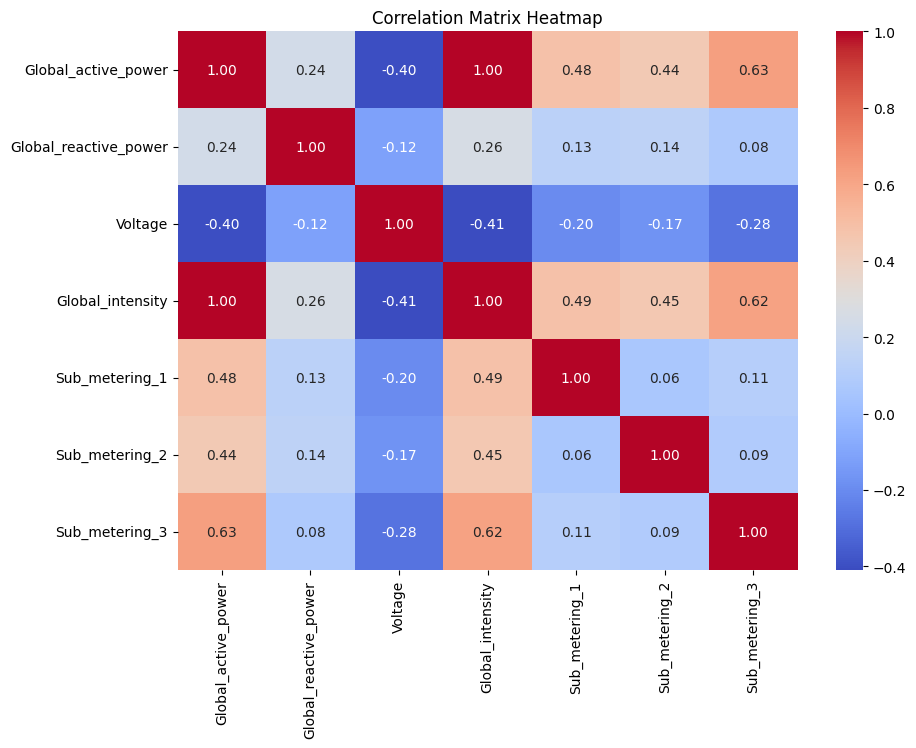

In [ ]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Correlation Analysis

#Set figure size
plt.figure(figsize=(10,7))

#Create heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,          #Show correlation values
    cmap='coolwarm',     #Color theme
    fmt='.2f'            #Decimal formatting
)

#Add title
plt.title("Correlation Matrix Heatmap")

#Display heatmap
plt.show()

In energy consumption time series forecasting, multiple forecasting models can be used to predict future electricity usage patterns. Comparing different models helps determine which algorithm provides the most accurate and reliable predictions. In this project, ARIMA, Prophet, and XGBoost models are compared because each model captures time series behavior differently.

The **ARIMA (AutoRegressive Integrated Moving Average) model** is a traditional statistical forecasting method that works well for linear time series data with trends and seasonality. It uses previous observations and forecast errors to make predictions. However, ARIMA may struggle with highly complex or non-linear patterns in energy consumption data.

The **Prophet model**, developed by Meta, is designed for time series forecasting with strong seasonal effects and missing values. It automatically handles trends, daily patterns, weekly seasonality, and holiday effects, making it easier to use and interpret for real-world forecasting tasks.

The **XGBoost (Extreme Gradient Boosting) model** is a powerful machine learning algorithm capable of learning complex non-linear relationships in data. Unlike ARIMA and Prophet, XGBoost requires engineered features such as hour, weekday, and lag values. It often provides higher forecasting accuracy when sufficient features and training data are available.

The performance of these models is typically evaluated using metrics such as **MAE (Mean Absolute Error)**, **RMSE (Root Mean Squared Error)**, and **MAPE (Mean Absolute Percentage Error)**. Lower values of these metrics indicate better forecasting performance. By comparing these models, we can identify the most suitable approach for accurate energy consumption forecasting.


ARIMA Performance
----------------------------
MAE : 1.0881702515384997
RMSE: 1.208299661053947

Prophet Performance
----------------------------
MAE : 0.47213976025821
RMSE: 0.6124864262753227

XGBoost Performance
----------------------------
MAE : 0.344893759067002
RMSE: 0.5004925762993486


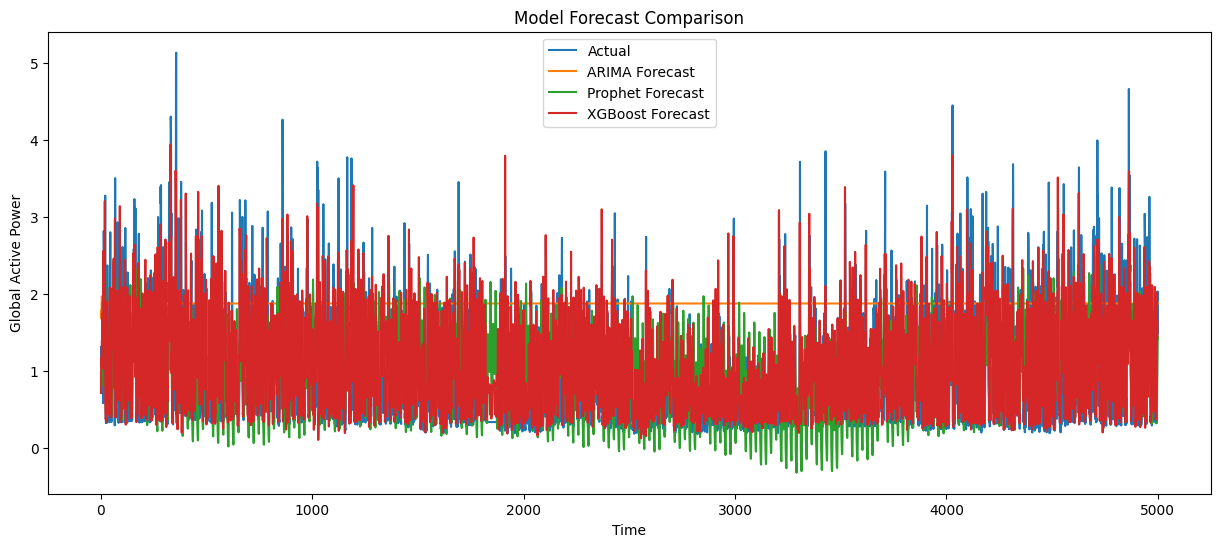

In [ ]:
#Import required libraries

import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt

#ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

#Prophet Model
from prophet import Prophet

#XGBoost Model
from xgboost import XGBRegressor

#Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

#Assign hourly_data to data for forecasting
data = hourly_data

#TRAIN-TEST Split

#Use 80% data for training and 20% for testing
train_size = int(len(data) * 0.80)

train = data[:train_size]
test = data[train_size:]

#Create ARIMA model
arima_model = ARIMA(train, order=(5,1,0))

#Train model
arima_fit = arima_model.fit()

#Forecast values
arima_forecast = arima_fit.forecast(steps=len(test))

#Prepare Prophet dataframe
prophet_df = data.reset_index()

#Rename columns for Prophet
prophet_df.columns = ['ds', 'y']

#Split data
prophet_train = prophet_df.iloc[:train_size]
prophet_test = prophet_df.iloc[train_size:]

#Create Prophet model
prophet_model = Prophet()

#Train model
prophet_model.fit(prophet_train)

#Create future dataframe
future = prophet_test[['ds']]

#Predict
forecast = prophet_model.predict(future)

#Prophet predictions
prophet_forecast = forecast['yhat'].values

#Feature Engineering for XGBoost

#Create dataframe for XGBoost
xgb_df = data.to_frame()

#Create lag features
xgb_df['Lag_1'] = xgb_df['Global_active_power'].shift(1)
xgb_df['Lag_2'] = xgb_df['Global_active_power'].shift(2)

#Create time-based features
xgb_df['Hour'] = xgb_df.index.hour
xgb_df['DayOfWeek'] = xgb_df.index.dayofweek

#Remove missing rows
xgb_df.dropna(inplace=True)

#Features and target
X = xgb_df[['Lag_1', 'Lag_2', 'Hour', 'DayOfWeek']]
y = xgb_df['Global_active_power']

#Split data
X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


#XGBOOST MODEL

#Create model
xgb_model = XGBRegressor()

#Train model
xgb_model.fit(X_train, y_train)

#Predict
xgb_forecast = xgb_model.predict(X_test)

#Evaluation Metrics

#Function to calculate metrics
def evaluate_model(true, predicted, model_name):

    mae = mean_absolute_error(true, predicted)

    rmse = np.sqrt(mean_squared_error(true, predicted))

    print(f"\n{model_name} Performance")
    print("----------------------------")
    print("MAE :", mae)
    print("RMSE:", rmse)

#Evaluate ARIMA
evaluate_model(test, arima_forecast, "ARIMA")

#Evaluate Prophet
evaluate_model(prophet_test['y'], prophet_forecast, "Prophet")

#Evaluate XGBoost
evaluate_model(y_test, xgb_forecast, "XGBoost")


#Visual Comparison

#Plot actual vs predicted values
plt.figure(figsize=(15,6))

#Actual values
plt.plot(test.values, label='Actual')

#ARIMA predictions
plt.plot(arima_forecast.values, label='ARIMA Forecast')

#Prophet predictions
plt.plot(prophet_forecast, label='Prophet Forecast')

#XGBoost predictions
plt.plot(xgb_forecast, label='XGBoost Forecast')

#Add title and labels
plt.title("Model Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Global Active Power")

#Show legend
plt.legend()

#Display graph
plt.show()

**Plotting Actual vs Forecasted Energy Usage** is an important step in evaluating the performance of forecasting models. This visualization helps compare the real observed energy consumption values with the predicted values generated by models such as ARIMA, Prophet, and XGBoost. By displaying both lines on the same graph, it becomes easier to identify how accurately the models capture trends, peaks, seasonal patterns, and fluctuations in electricity usage. A forecast line that closely follows the actual values indicates better model performance and forecasting accuracy. Visualization also helps detect overfitting, underfitting, or prediction errors that may not be obvious from evaluation metrics alone.

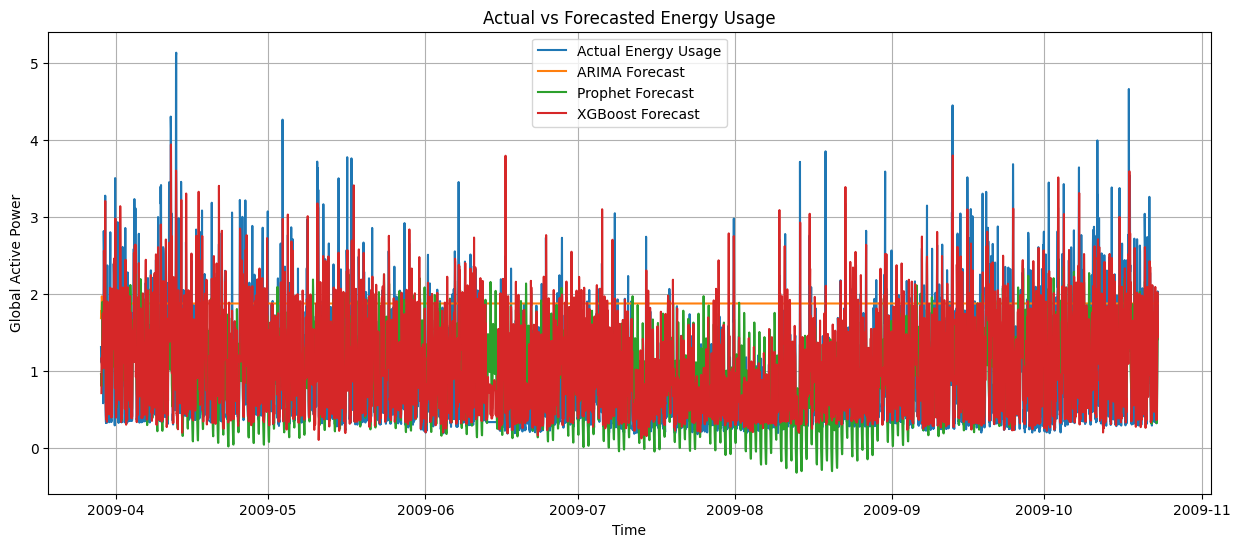

In [ ]:
#Plot Actual vs Forecasted Energy Usage

#Import required libraries
import matplotlib.pyplot as plt

#Set figure size
plt.figure(figsize=(15,6))

#Plot Actual Energy Consumption

#Plot actual test values
plt.plot(
    test.index,
    test.values,
    label='Actual Energy Usage'
)

#Plot ARIMA predicted values
plt.plot(
    test.index,
    arima_forecast.values,
    label='ARIMA Forecast'
)

#Plot Prophet predicted values
plt.plot(
    prophet_test['ds'],
    prophet_forecast,
    label='Prophet Forecast'
)

#Plot XGBoost predicted values
plt.plot(
    y_test.index,
    xgb_forecast,
    label='XGBoost Forecast'
)

#Add title
plt.title("Actual vs Forecasted Energy Usage")

#Add x-axis label
plt.xlabel("Time")

#Add y-axis label
plt.ylabel("Global Active Power")

#Display legend
plt.legend()

#Add grid for better readability
plt.grid(True)

#Display Graph
plt.show()

**Conclusion and Insights:** The Energy Consumption Time Series Forecasting project successfully analyzed historical electricity usage data and applied multiple forecasting techniques to predict future energy consumption patterns. Through data preprocessing, time series parsing, resampling, feature engineering, exploratory data analysis, and model comparison, valuable insights were obtained regarding household energy usage behavior. Time-based features such as hour of day, weekdays, and weekends helped capture recurring consumption trends and improved forecasting performance. Exploratory analysis revealed that energy usage changes significantly across different times of the day and may exhibit seasonal or repetitive patterns.

Among the forecasting models, ARIMA provided a strong statistical baseline for linear trends, Prophet effectively handled seasonality and trend components, while XGBoost demonstrated the ability to learn more complex and non-linear relationships using engineered features. Performance evaluation using metrics such as MAE and RMSE helped identify the most accurate forecasting model for the dataset. Visualization of actual versus predicted energy consumption further highlighted the strengths and weaknesses of each model. Additionally, the correlation matrix provided insights into relationships between electrical measurements, showing that variables such as global intensity and sub-metering features have strong associations with overall power consumption.

Overall, this project demonstrates how machine learning and time series forecasting techniques can be used to analyze and predict energy demand effectively. Accurate forecasting can support better energy management, efficient resource utilization, and smarter decision-making in power consumption planning.